In [1]:
from hydra import initialize, compose
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.patches import Patch
import re
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict, Counter
from itertools import product
from ergochemics.standardize import standardize_reaction, hash_reaction, standardize_smiles
from functools import partial

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

def find_between_rules(s):
    match = re.search(r'_rules_(.+?)_rules_', s)
    return match.group(1) if match else None

def _check_pairs(lhs, rhs, pxcheck):
    pairs = [elt for elt in  product(lhs, rhs) if elt in pxcheck]
    rm_l, rm_r = zip(*pairs) if pairs else ([], [])
    _lhs = [elt for elt in lhs if elt not in rm_l]
    _rhs = [elt for elt in rhs if elt not in rm_r]
    return _lhs, _rhs

In [2]:
cutoff_date = 2015
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub = pub.explode("publication_dates")
pub = pub.group_by("id").agg(
    pl.col("publication_dates").min(),
    pl.col("smarts").first()
).filter(pl.col("publication_dates") >= cutoff_date).rename({"publication_dates": "pub_date"})
tot_pub_rxns = pub.shape[0]
print(f"Total reactions with publication date >= {cutoff_date}: {tot_pub_rxns:,}")
pub.head()

Total reactions with publication date >= 2015: 4,466


id,pub_date,smarts
str,i32,str
"""d831ebc9c416ad24e8b6befa93972d…",2017,"""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…"
"""f1dcc65499c7f66e18ba3d9a23e1d4…",2024,"""*.*NC(C(*)=O)C1CC1C.CC1OC(n2cn…"
"""c82e00e5d6de9b1ba03586a6491669…",2015,"""COc1ccc2c(c1OC)C(O)[N+]1(C)CCc…"
"""23edf49d9e837c2544dfba75745a2e…",2024,"""CC(C)C1CC(O)C2C1(C)CCC1(C)C3=C…"
"""0b68c4dcaac3d97b5a66c0157c649d…",2015,"""*NC(CCCNC(=N)NC1OC(C)C(O)C(O)C…"


In [5]:
# For coreactant filtering for unbalanced rules

upxcheck = pl.read_csv(
    Path(cfg.coreactants) / "unpaired.tsv",
    separator="\t"
)['smiles'].to_list()

paired = pl.read_csv(
    Path(cfg.coreactants) / "paired.tsv",
    separator="\t"
)

to_rm = ['2-KETOGLUTARATE', 'GLT']

common = pl.read_csv(
    Path(cfg.coreactants) / "metacyc_coreactants.tsv",
    separator="\t"
).with_columns(
    pl.col("SMILES").map_elements(standardize_smiles, return_dtype=pl.String)
).filter(
    ~pl.col("Name").is_in(to_rm)
)['SMILES'].to_list() + [
    "NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(O)C3O)C(O)C2O)c1",
    "NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(O)C3O)C(O)C2O)C=CC1",
]

upxcheck = list(set(upxcheck + common))

pxcheck = [(row['smiles_1'], row['smiles_2']) for row in paired.iter_rows(named=True)] + [(row['smiles_2'], row['smiles_1']) for row in paired.iter_rows(named=True)]
check_pairs = partial(_check_pairs, pxcheck=pxcheck)

[10:36:28] WARNING: not removing hydrogen atom without neighbors


In [6]:
metrics = []
unbalanced_rules = ['retrobiocat', 'evodex']
for fn in (Path(cfg.interim_data) / "std_pickaxe_rxns").glob("*.parquet"):
    _name = find_between_rules(fn.stem)
    unbalanced = any(rule in _name for rule in unbalanced_rules)

    suffix = f"_before_{cutoff_date}" if "retrobiocat" not in _name else ""

    post_mappings_fn = Path(cfg.raw_data) / "mappings" / f"mappings_known_reactions_after_2015_x_{_name}_rules{suffix}.parquet"
    if post_mappings_fn.exists():
        maps = pl.read_parquet(
            Path(cfg.raw_data) / "mappings" / f"mappings_known_reactions_after_2015_x_{_name}_rules{suffix}.parquet"
        )
    else:
        maps = pl.read_parquet(
            Path(cfg.raw_data) / "mappings" / f"mapped_known_reactions_x_{_name}_rules{suffix}.parquet"
        )
    
    pred = pl.read_parquet(fn) # Expansion

    if "evodex" in _name:
        maps = maps.with_columns(
            pl.col("smarts").str.split(">>").list.get(0).alias("lhs"),
            pl.col("smarts").str.split(">>").list.get(1).alias("rhs"),
            pl.col("rule").str.split(">>").list.get(0).alias("lhs_rule"),
            pl.col("rule").str.split(">>").list.get(1).alias("rhs_rule")
        ).with_columns(
            pl.col("lhs").str.split(".").len().alias("n_rcts"),
            pl.col("rhs").str.split(".").len().alias("n_pdts"),
            pl.col("lhs_rule").str.split(".").len().alias("n_rcts_rule"),
            pl.col("rhs_rule").str.split(".").len().alias("n_pdts_rule"),
        ).filter(
            (pl.col("n_rcts_rule") <= pl.col("n_rcts")) | (pl.col("n_pdts_rule") <= pl.col("n_pdts"))
        )

    if unbalanced:
        maps = maps.with_columns(
        pl.col("smarts").map_elements(standardize_reaction, return_dtype=pl.String).alias("std_smarts")
        ).with_columns(
            pl.col("std_smarts").map_elements(hash_reaction, return_dtype=pl.String).alias("gen_id"),
            pl.col("std_smarts").str.split(">>").list.get(0).str.split(".").list.unique().alias("unique_rcts"),
            pl.col("std_smarts").str.split(">>").list.get(1).str.split(".").list.unique().alias("unique_pdts"),
        )
        maps = maps.join(other=pub, left_on='rxn_id', right_on='id', how='inner', suffix='_true').with_columns(
            pl.col("smarts_true").str.split(">>").list.get(0).str.split(".").list.unique().alias("true_rcts"),
            pl.col("smarts_true").str.split(">>").list.get(1).str.split(".").list.unique().alias("true_pdts"),
        )
        gb = maps.group_by("rxn_id").agg(
            pl.col("unique_rcts").list.explode().unique().alias("rcts"),
            pl.col("unique_pdts").list.explode().unique().alias("pdts"),
            pl.col("true_rcts").first(),
            pl.col("true_pdts").first(),
        ).with_columns(
            pl.col("true_rcts").list.set_difference(pl.col("rcts")).alias("missing_rcts"),
            pl.col("true_pdts").list.set_difference(pl.col("pdts")).alias("missing_pdts"),
        ).with_columns(
            pl.col("missing_rcts").list.set_difference(upxcheck).alias("soft_missing_rcts"),
            pl.col("missing_pdts").list.set_difference(upxcheck).alias("soft_missing_pdts")
        ).with_columns(
            pl.struct("soft_missing_rcts", "soft_missing_pdts").map_elements(
                lambda x: check_pairs(x["soft_missing_rcts"], x["soft_missing_pdts"]),
                return_dtype=pl.Struct({"pxchecked_lhs": pl.List(pl.String), "pxchecked_rhs": pl.List(pl.String)})
            ).alias("res")
        ).unnest("res").drop(
            "soft_missing_rcts",
            "soft_missing_pdts"
        ).rename({"pxchecked_lhs": "soft_missing_rcts", "pxchecked_rhs": "soft_missing_pdts"})
        incl_partial_maps = gb.unique("rxn_id").height
        strict_maps = gb.filter(
            pl.col("missing_rcts").list.len() == 0,
            pl.col("missing_pdts").list.len() == 0
        ).unique("rxn_id").height
        fuzzy_maps = gb.filter(
            pl.col("soft_missing_rcts").list.len() == 0,
            pl.col("soft_missing_pdts").list.len() == 0
        ).unique("rxn_id").height

    else:
        maps = maps.unique(subset=["rxn_id"])
        strict_maps = maps.join(pub, left_on="rxn_id", right_on="id", how="inner").height
        incl_partial_maps = strict_maps
        fuzzy_maps = strict_maps
    
    pred = pred.unique(subset=["id"])
    
    metrics.append(
        {
            "name": _name,
            "num_rxns": len(pred),
            "strict_maps": strict_maps,
            "incl_partial_maps": incl_partial_maps,
            "fuzzy_maps": fuzzy_maps,
            "strict_recall": strict_maps / tot_pub_rxns,
            "incl_partial_recall": incl_partial_maps / tot_pub_rxns,
            "fuzzy_recall": fuzzy_maps / tot_pub_rxns,
            "strict_precision": strict_maps / len(pred),
            "incl_partial_precision": incl_partial_maps / len(pred),
            "fuzzy_precision": fuzzy_maps / len(pred),
            "fn": fn,
        }
    )

metrics.append(
    {
        "name": "rc_plus_0",
        "num_rxns": 7_666_721,
        "strict_maps": 2_690,
        "incl_partial_maps": 2_690,
        "fuzzy_maps": 2_690,
        "strict_recall": 2_690 / tot_pub_rxns,
        "incl_partial_recall": 2_690 / tot_pub_rxns,
        "fuzzy_recall": 2_690 / tot_pub_rxns,
        "strict_precision": 2_690 / 7_666_721,
        "incl_partial_precision": 2_690 / 7_666_721,
        "fuzzy_precision": 2_690 / 7_666_721,
        "fn": None,
    }
)
metrics = pl.DataFrame(metrics).sort("fuzzy_recall", descending=True)
metrics.head(10)

name,num_rxns,strict_maps,incl_partial_maps,fuzzy_maps,strict_recall,incl_partial_recall,fuzzy_recall,strict_precision,incl_partial_precision,fuzzy_precision,fn
str,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,object
"""rc_plus_0""",7666721,2690,2690,2690,0.602329,0.602329,0.602329,0.000351,0.000351,0.000351,null
"""mechinferred_dt_932""",723410,2519,2519,2519,0.564039,0.564039,0.564039,0.003482,0.003482,0.003482,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_932_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rdchiral""",173551,2274,2274,2274,0.50918,0.50918,0.50918,0.013103,0.013103,0.013103,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rdchiral_rules_before_2015_w_coreactants_aplusb_True.parquet
"""imt""",1225336,2242,2242,2242,0.502015,0.502015,0.502015,0.00183,0.00183,0.00183,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_imt_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_069""",161815,2238,2238,2238,0.50112,0.50112,0.50112,0.013831,0.013831,0.013831,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_069_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Bm""",668791,1710,3245,2176,0.382893,0.726601,0.487237,0.002557,0.004852,0.003254,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_w_metacyc_coreactants_rules_evodex_Bm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Cm""",157631,1641,2423,2098,0.367443,0.542544,0.469772,0.01041,0.015371,0.01331,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_w_metacyc_coreactants_rules_evodex_Cm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Dm""",133704,1623,2405,2092,0.363412,0.538513,0.468428,0.012139,0.017987,0.015647,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_w_metacyc_coreactants_rules_evodex_Dm_rules_before_2015_w_coreactants_aplusb_True.parquet
"""evodex_Em""",128286,1546,2348,2052,0.346171,0.52575,0.459472,0.012051,0.018303,0.015996,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_w_metacyc_coreactants_rules_evodex_Em_rules_before_2015_w_coreactants_aplusb_True.parquet


In [7]:
Rs = [0, 1, 2, 3, 4]
dts = ['932', '069', '021', '009', '005']
dts_dmo = ['961', '244', '106', '059', '035']
others = ['mechinformed', 'rdchiral', 'imt', "evodex_Bm", "evodex_Cm", "evodex_Dm", "evodex_Em", "retrobiocat"]
mechinferred_template_sizes = defaultdict(list)
rcr_template_sizes = defaultdict(list)
dmo_template_sizes = defaultdict(list)
bad_rules = {'rcr': set(), 'mechinferred': set()}
rcr_rules = []
other_rules = []
other_template_sizes = defaultdict(list)

for dt in dts:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        mechinferred_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for R in Rs:
    if R == 0:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_0_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_{R}_rules_before_{cutoff_date}.csv",
        )
    rcr_rules.append(df)
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        rcr_template_sizes[R].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for other in others:
    if other == 'imt':
        df = pl.read_csv(
            Path(cfg.rules) / f"imt_rules_before_{cutoff_date}.csv",
        )
    elif other == "retrobiocat":
        df = pl.read_csv(
            Path(cfg.rules) / f"retrobiocat_rules.csv",
        )
    else:
        df = pl.read_csv(
            source=Path(cfg.rules) / f"{other}_rules_before_{cutoff_date}.csv",
            ignore_errors=True,
        )
    other_rules.append(df)
    for row in df.iter_rows(named=True):
            sma = row["smarts"]
            rxn = AllChem.ReactionFromSmarts(sma)
            other_template_sizes[other].append(
                sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
            )

median_template_size = {}

for name in metrics["name"].unique().to_list():
    vals = None

    if name.startswith("mechinferred_dt_"):
        dt = name.split("_")[-1]
        vals = mechinferred_template_sizes.get(dt, [])
    elif name.startswith("rc_plus_"):
        R = int(name.split("_")[-1])
        vals = rcr_template_sizes.get(R, [])
    else:
        vals = other_template_sizes.get(name, [])

    median_template_size[name] = pl.Series(vals).median() if vals else None

median_template_size


{'retrobiocat': 6.0,
 'mechinferred_dt_009': 34.0,
 'mechinformed': 7.0,
 'evodex_Cm': 9.0,
 'rc_plus_4': 21.0,
 'imt': 3.0,
 'evodex_Dm': 10.0,
 'evodex_Bm': 4.0,
 'evodex_Em': 11.0,
 'mechinferred_dt_932': 4.0,
 'rc_plus_2': 13.0,
 'rdchiral': 10.0,
 'rc_plus_3': 17.0,
 'mechinferred_dt_021': 30.0,
 'mechinferred_dt_005': 40.0,
 'rc_plus_0': 5.0,
 'rc_plus_1': 8.0,
 'mechinferred_dt_069': 18.0}

In [8]:
# Plot cfg

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

exp_labels = {
    'mechinformed': "Distilled",
    'mechinferred_dt_932': "Learned >0.932",
    'mechinferred_dt_069': "Learned >0.069",
    'mechinferred_dt_021': "Learned >0.021",
    'mechinferred_dt_009': "Learned >0.009",
    'mechinferred_dt_005': "Learned >0.005",
    'rc_plus_0': "RC + 0",
    'rc_plus_1': "RC + 1",
    'rc_plus_2': "RC + 2",
    'rc_plus_3': "RC + 3",
    'rc_plus_4': "RC + 4",
    'imt': "Pathway-level clustering",
    'rdchiral': "RDChiral",
    "retrobiocat": "RetroBioCat",
    "evodex_Bm": "EVODEX Bm",
    "evodex_Cm": "EVODEX Cm",
    "evodex_Dm": "EVODEX Dm",
    "evodex_Em": "EVODEX Em"
}

colors = {
    'mechinformed': matplotlib.colors.to_rgba("green"),
    'mechinferred_dt_932': matplotlib.colors.to_rgba("purple", alpha=0.3),
    'mechinferred_dt_069': matplotlib.colors.to_rgba("purple", alpha=0.45),
    'mechinferred_dt_021': matplotlib.colors.to_rgba("purple", alpha=0.6),
    'mechinferred_dt_009': matplotlib.colors.to_rgba("purple", alpha=0.85),
    'mechinferred_dt_005': matplotlib.colors.to_rgba("purple", alpha=1.0),
    'rc_plus_0': matplotlib.colors.to_rgba("black", alpha=0.3),
    'rc_plus_1': matplotlib.colors.to_rgba("black", alpha=0.45),
    'rc_plus_2': matplotlib.colors.to_rgba("black", alpha=0.6),
    'rc_plus_3': matplotlib.colors.to_rgba("black", alpha=0.85),
    'rc_plus_4': matplotlib.colors.to_rgba("black", alpha=1.0),
    'imt': matplotlib.colors.to_rgba("darkorange"),
    'rdchiral': matplotlib.colors.to_rgba("blue"),
    "retrobiocat": matplotlib.colors.to_rgba("cyan"),
    "evodex_Bm": matplotlib.colors.to_rgba("red", alpha=0.3),
    "evodex_Cm": matplotlib.colors.to_rgba("red", alpha=0.45),
    "evodex_Dm": matplotlib.colors.to_rgba("red", alpha=0.6),
    "evodex_Em": matplotlib.colors.to_rgba("red", alpha=0.9),
}

exp_names = list(exp_labels.keys())

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
]

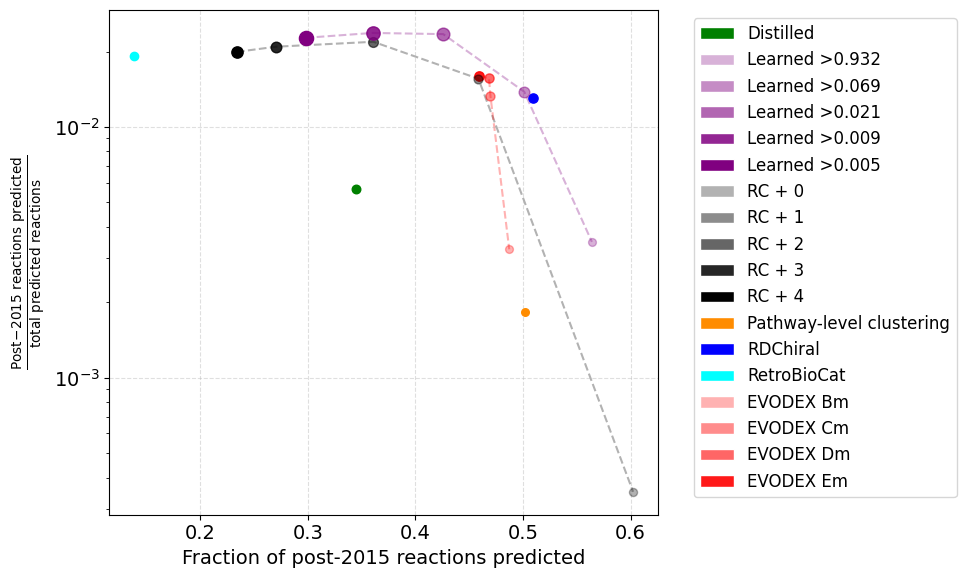

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24
map_criteria = "fuzzy"

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
]

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []
evodex_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    
    if name not in exp_labels:
        continue

    x = row[f"{map_criteria}_recall"]
    y = row[f"{map_criteria}_precision"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_"):
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))
    elif name.startswith("evodex_"):
        evodex_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect red dots (evodex)
if evodex_data:
    evodex_data = sorted(evodex_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in evodex_data],
        [p[1] for p in evodex_data],
        color="red",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(Path(cfg.figures) / f"after_{cutoff_date}_generative_performance.svg")
plt.show()
